# Portfolio Project: Forecasting Report Usage with Auto-ARIMA (Synthetic Data)

This notebook demonstrates an end-to-end forecasting workflow suitable for a data science portfolio:
- Synthetic dataset design (realistic report-usage behavior)
- Data quality checks
- Per-report time-series modeling with Auto-ARIMA
- Baseline benchmarking and model acceptance criteria
- Forecast + metrics output tables
- Realized error backfill process
- Azure Databricks ML pipeline adaptation

## Why synthetic data?
This version is fully shareable on GitHub and does not depend on private Power BI or enterprise data sources.


## Run Checklist

1. Install dependencies: `pandas`, `numpy`, `scikit-learn`, `pmdarima`, `matplotlib`
2. Run all cells in order
3. Review `latest` and `history` CSV outputs in the `outputs/` folder
4. Optional: adapt Databricks cells at the end for production deployment


In [4]:
import os
import uuid
from dataclasses import dataclass
from pathlib import Path
from typing import Dict, List, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error
from pmdarima import auto_arima


In [5]:
# -----------------------------
# Configuration
# -----------------------------
DATE_COL = "Date"
REPORT_ID_COL = "Report Guid"
REPORT_NAME_COL = "Report Name"
USER_COL = "User Id"
VIEWS_COL = "Occurrences"

M = 7  # weekly seasonality for SARIMA
SEASONALITY_DAYS = 7

# Data sufficiency criteria
MIN_DAYS = 90
MIN_NONZERO_DAYS = 35
MIN_NONZERO_RATIO = 0.25
MIN_TOTAL_VIEWS = 120

# Model criteria
TRAIN_TEST_FRACTION = 0.8
FORECAST_HORIZON_DAYS = 30
MAX_MAE_RATIO_TO_MEAN = 0.6
MIN_IMPROVEMENT_VS_NAIVE = 0.10
MIN_IMPROVEMENT_VS_SEASONAL_NAIVE = 0.10

# Optional report filter. Use set() for all reports.
ALLOWED_REPORT_NAMES = set()

# Output paths (portable, project-local)
OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

LATEST_FORECAST_FILE = OUTPUT_DIR / "report_view_forecasts_latest.csv"
LATEST_METRICS_FILE = OUTPUT_DIR / "report_view_metrics_latest.csv"
FORECASTS_HISTORY_FILE = OUTPUT_DIR / "forecasts_history.csv"
METRICS_HISTORY_FILE = OUTPUT_DIR / "metrics_history.csv"
REALIZED_ERRORS_FILE = OUTPUT_DIR / "realized_errors_history.csv"

RUN_TIMESTAMP = pd.Timestamp.now()
RUN_ID = RUN_TIMESTAMP.strftime("%Y%m%d_%H%M%S") + "_" + str(uuid.uuid4())[:8]
MODEL_NAME = "AutoARIMA_m7_daily_report_views"

print(f"RUN_ID: {RUN_ID}")
print(f"RUN_TIMESTAMP: {RUN_TIMESTAMP}")
print(f"OUTPUT_DIR: {OUTPUT_DIR.resolve()}")


RUN_ID: 20260324_215051_0effa758
RUN_TIMESTAMP: 2026-03-24 21:50:51.272935
OUTPUT_DIR: /Users/masegomodibane/Documents/GitHub/Data Science Projects /Forecasting Report Usage/GitHub Final Version/outputs


## 1) Synthetic Dataset Generation

This generator simulates common usage patterns:
- Weekly behavior (weekday high, weekend lower)
- Different report popularity levels
- Mild trend over time
- Random quiet/zero-activity days
- User-level rows with an `Occurrences` measure


In [6]:
def generate_synthetic_report_usage(
    n_reports: int = 12,
    start_date: str = "2024-01-01",
    end_date: str = "2025-12-31",
    random_seed: int = 42,
) -> pd.DataFrame:
    rng = np.random.default_rng(random_seed)

    date_index = pd.date_range(start=start_date, end=end_date, freq="D")
    report_ids = [f"RPT-{i:03d}" for i in range(1, n_reports + 1)]
    report_names = [f"Operations Usage Report {i:02d}" for i in range(1, n_reports + 1)]

    rows = []
    for rid, rname in zip(report_ids, report_names):
        base_level = rng.uniform(8, 120)
        trend = rng.uniform(-0.03, 0.08)
        noise_scale = rng.uniform(2, 15)
        zero_day_prob = rng.uniform(0.02, 0.18)

        # Weekly profile (Mon..Sun)
        weekly_profile = np.array([1.25, 1.20, 1.15, 1.10, 1.00, 0.55, 0.45])
        weekly_profile = weekly_profile * rng.uniform(0.85, 1.20)

        for day_number, dt in enumerate(date_index):
            weekday_factor = weekly_profile[dt.weekday()]
            trend_factor = max(0.2, 1 + trend * day_number / 365)
            expected = base_level * weekday_factor * trend_factor
            noisy_expected = max(0, expected + rng.normal(0, noise_scale))

            if rng.uniform(0, 1) < zero_day_prob:
                total_views = 0
            else:
                total_views = int(rng.poisson(max(0.1, noisy_expected)))

            if total_views == 0:
                # Keep occasional explicit zero rows so gaps aren't the only source of zeros
                if rng.uniform(0, 1) < 0.15:
                    rows.append(
                        {
                            DATE_COL: dt,
                            REPORT_ID_COL: rid,
                            REPORT_NAME_COL: rname,
                            USER_COL: f"U{rng.integers(1, 300):04d}",
                            VIEWS_COL: 0,
                        }
                    )
                continue

            # Split daily total into user-level rows so grouping logic is realistic
            n_users = int(np.clip(rng.poisson(lam=max(1, np.sqrt(total_views))), 1, 80))
            shares = rng.dirichlet(np.ones(n_users))
            user_counts = np.maximum(1, np.round(shares * total_views).astype(int))

            # Adjust rounding drift
            drift = total_views - int(user_counts.sum())
            if drift != 0:
                user_counts[0] += drift
                if user_counts[0] < 1:
                    user_counts[0] = 1

            for count in user_counts:
                rows.append(
                    {
                        DATE_COL: dt,
                        REPORT_ID_COL: rid,
                        REPORT_NAME_COL: rname,
                        USER_COL: f"U{rng.integers(1, 300):04d}",
                        VIEWS_COL: int(max(0, count)),
                    }
                )

    df = pd.DataFrame(rows)
    df[DATE_COL] = pd.to_datetime(df[DATE_COL])
    return df.sort_values([DATE_COL, REPORT_ID_COL, USER_COL]).reset_index(drop=True)


report_views_df = generate_synthetic_report_usage()
print(report_views_df.shape)
report_views_df.head()


(67930, 5)


,Date,Report Guid,Report Name,User Id,Occurrences
0,2024-01-01,RPT-001,Operations Usage Report 01,U0023,22
1,2024-01-01,RPT-001,Operations Usage Report 01,U0039,1
2,2024-01-01,RPT-001,Operations Usage Report 01,U0057,5
3,2024-01-01,RPT-001,Operations Usage Report 01,U0068,15
4,2024-01-01,RPT-001,Operations Usage Report 01,U0099,5


In [7]:
# Quick EDA snapshot
summary = (
    report_views_df.groupby(REPORT_NAME_COL)[VIEWS_COL]
    .agg(total_views="sum", rows="count", avg_occurrence_per_row="mean")
    .sort_values("total_views", ascending=False)
)
summary.head(10)


,total_views,rows,avg_occurrence_per_row
Report Name,,,
Operations Usage Report 02,91712,7925,11.572492
Operations Usage Report 05,91027,7506,12.127232
Operations Usage Report 07,83994,7340,11.443324
Operations Usage Report 04,81854,7172,11.412995
Operations Usage Report 12,62772,6093,10.302314
Operations Usage Report 10,53731,6142,8.748128
Operations Usage Report 03,53655,5913,9.074074
Operations Usage Report 01,52939,5968,8.870476
Operations Usage Report 06,50219,5395,9.308434


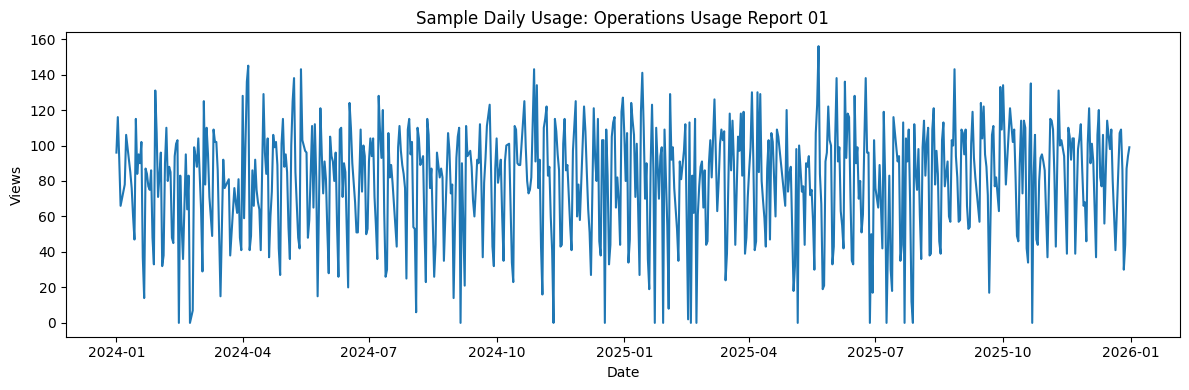

In [8]:
# Plot one sample report's daily total behavior
sample_report = report_views_df[REPORT_NAME_COL].iloc[0]
daily_sample = (
    report_views_df[report_views_df[REPORT_NAME_COL] == sample_report]
    .groupby(DATE_COL)[VIEWS_COL]
    .sum()
)

plt.figure(figsize=(12, 4))
plt.plot(daily_sample.index, daily_sample.values)
plt.title(f"Sample Daily Usage: {sample_report}")
plt.xlabel("Date")
plt.ylabel("Views")
plt.tight_layout()
plt.show()


## 2) Data Quality Checks

Basic checks before modeling help avoid hidden issues in production runs.


In [6]:
def run_data_quality_checks(df: pd.DataFrame) -> pd.DataFrame:
    checks = []

    checks.append({"check": "row_count", "value": len(df), "status": "ok" if len(df) > 0 else "fail"})

    for col in [DATE_COL, REPORT_ID_COL, REPORT_NAME_COL, USER_COL, VIEWS_COL]:
        null_count = int(df[col].isna().sum())
        checks.append(
            {
                "check": f"nulls_{col}",
                "value": null_count,
                "status": "ok" if null_count == 0 else "warn",
            }
        )

    duplicate_key_count = int(
        df.duplicated(subset=[DATE_COL, REPORT_ID_COL, REPORT_NAME_COL, USER_COL, VIEWS_COL]).sum()
    )
    checks.append(
        {
            "check": "exact_duplicate_rows",
            "value": duplicate_key_count,
            "status": "ok" if duplicate_key_count == 0 else "warn",
        }
    )

    min_date = df[DATE_COL].min()
    max_date = df[DATE_COL].max()
    checks.append({"check": "min_date", "value": str(min_date.date()), "status": "ok"})
    checks.append({"check": "max_date", "value": str(max_date.date()), "status": "ok"})

    negative_occurrences = int((df[VIEWS_COL] < 0).sum())
    checks.append(
        {
            "check": "negative_occurrences",
            "value": negative_occurrences,
            "status": "ok" if negative_occurrences == 0 else "fail",
        }
    )

    return pd.DataFrame(checks)


dq = run_data_quality_checks(report_views_df)
dq


,check,value,status
0,row_count,67930,ok
1,nulls_Date,0,ok
2,nulls_Report Guid,0,ok
3,nulls_Report Name,0,ok
4,nulls_User Id,0,ok
5,nulls_Occurrences,0,ok
6,exact_duplicate_rows,81,warn
7,min_date,2024-01-01,ok
8,max_date,2025-12-31,ok
9,negative_occurrences,0,ok


## 3) Build Per-Report Daily Series


In [7]:
def build_daily_series_for_all_reports(
    df: pd.DataFrame,
    report_id_col: str = REPORT_ID_COL,
    date_col: str = DATE_COL,
) -> Tuple[Dict[str, pd.Series], Dict[str, str]]:
    d = df.copy()
    d[date_col] = pd.to_datetime(d[date_col])

    if VIEWS_COL not in d.columns:
        raise KeyError(f"Expected column '{VIEWS_COL}' is missing")

    d[VIEWS_COL] = pd.to_numeric(d[VIEWS_COL], errors="coerce").fillna(0)

    series_dict: Dict[str, pd.Series] = {}
    name_lookup: Dict[str, str] = {}

    for rid, g in d.groupby(report_id_col):
        report_name = g[REPORT_NAME_COL].iloc[0]
        name_lookup[rid] = report_name

        daily = (
            g.groupby(date_col)[VIEWS_COL]
            .sum()
            .rename("Views")
            .sort_index()
        )

        full_index = pd.date_range(daily.index.min(), daily.index.max(), freq="D")
        daily_full = daily.reindex(full_index, fill_value=0)
        daily_full.index.name = date_col

        series_dict[rid] = daily_full

    return series_dict, name_lookup


## 4) Data Sufficiency Filter


In [8]:
def filter_by_data_criteria(
    series_dict: Dict[str, pd.Series],
    min_days: int = MIN_DAYS,
    min_nonzero_days: int = MIN_NONZERO_DAYS,
    min_nonzero_ratio: float = MIN_NONZERO_RATIO,
    min_total_views: int = MIN_TOTAL_VIEWS,
) -> Tuple[List[str], pd.DataFrame]:
    records = []
    passing: List[str] = []

    for rid, s in series_dict.items():
        total_days = int(s.size)
        nonzero_days = int((s > 0).sum())
        nonzero_ratio = nonzero_days / total_days if total_days else 0.0
        total_views = int(s.sum())

        passes = (
            total_days >= min_days
            and nonzero_days >= min_nonzero_days
            and nonzero_ratio >= min_nonzero_ratio
            and total_views >= min_total_views
        )

        records.append(
            {
                "report_id": rid,
                "total_days": total_days,
                "nonzero_days": nonzero_days,
                "nonzero_ratio": nonzero_ratio,
                "total_views": total_views,
                "passes_data_criteria": passes,
            }
        )
        if passes:
            passing.append(rid)

    return passing, pd.DataFrame.from_records(records)


## 5) ARIMA Training, Baselines, and Acceptance Criteria

Improvements applied:
- Consistent acceptance logic (no mismatch between baseline checks)
- Added WAPE metric for zero-heavy series
- Explicit clipping of negative forecasts/intervals
- Defensive datetime handling in later history steps


In [9]:
def naive_forecast_last_value(y_train: pd.Series, steps: int) -> np.ndarray:
    return np.full(shape=steps, fill_value=float(y_train.iloc[-1]), dtype=float)


def seasonal_naive_forecast(
    y_train: pd.Series,
    steps: int,
    season_length: int = SEASONALITY_DAYS,
) -> np.ndarray:
    if len(y_train) < season_length:
        return naive_forecast_last_value(y_train, steps)
    last_season = y_train.iloc[-season_length:].to_numpy(dtype=float)
    repeats = int(np.ceil(steps / season_length))
    return np.tile(last_season, repeats)[:steps]


def wape(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    denom = np.abs(y_true).sum()
    if denom == 0:
        return np.nan
    return np.abs(y_true - y_pred).sum() / denom


def train_and_evaluate_arima(
    y: pd.Series,
    train_fraction: float = TRAIN_TEST_FRACTION,
    horizon_days: int = FORECAST_HORIZON_DAYS,
) -> Tuple[object, pd.DataFrame, dict]:
    y = y.astype(float)
    n = len(y)
    train_size = int(n * train_fraction)

    if train_size < 30 or n - train_size < 7:
        raise ValueError("Series too short for robust backtest split")

    y_train = y.iloc[:train_size]
    y_test = y.iloc[train_size:]

    model = auto_arima(
        y_train,
        seasonal=True,
        m=M,
        stepwise=True,
        suppress_warnings=True,
        error_action="ignore",
        trace=False,
    )

    n_test = len(y_test)
    fc_test, conf_test = model.predict(n_periods=n_test, return_conf_int=True)

    # Non-negative clipping for count data
    fc_test = np.clip(fc_test, 0, None)
    conf_test = np.clip(np.asarray(conf_test, dtype=float), 0, None)

    backtest_df = pd.DataFrame(
        {
            "forecast": fc_test,
            "lower_ci": conf_test[:, 0],
            "upper_ci": conf_test[:, 1],
            "actual": y_test.values,
        },
        index=y_test.index,
    )

    backtest_df["error"] = backtest_df["actual"] - backtest_df["forecast"]
    backtest_df["abs_error"] = backtest_df["error"].abs()
    backtest_df["pct_error"] = (
        backtest_df["abs_error"] / backtest_df["actual"].replace(0, np.nan)
    ) * 100

    mae_arima = mean_absolute_error(y_test, fc_test)
    rmse_arima = np.sqrt(mean_squared_error(y_test, fc_test))
    wape_arima = wape(y_test.to_numpy(), fc_test)
    avg_level = y_test.mean()

    naive_fc = naive_forecast_last_value(y_train, n_test)
    seasonal_naive_fc = seasonal_naive_forecast(y_train, n_test)

    mae_naive = mean_absolute_error(y_test, naive_fc)
    rmse_naive = np.sqrt(mean_squared_error(y_test, naive_fc))
    wape_naive = wape(y_test.to_numpy(), naive_fc)

    mae_seasonal_naive = mean_absolute_error(y_test, seasonal_naive_fc)
    rmse_seasonal_naive = np.sqrt(mean_squared_error(y_test, seasonal_naive_fc))
    wape_seasonal_naive = wape(y_test.to_numpy(), seasonal_naive_fc)

    model.update(y_test)
    fc_future, conf_future = model.predict(n_periods=horizon_days, return_conf_int=True)

    # Non-negative clipping for count data
    fc_future = np.clip(fc_future, 0, None)
    conf_future = np.clip(np.asarray(conf_future, dtype=float), 0, None)

    future_dates = pd.date_range(
        start=y.index[-1] + pd.Timedelta(days=1), periods=horizon_days, freq="D"
    )

    future_df = pd.DataFrame(
        {
            "forecast": fc_future,
            "lower_ci": conf_future[:, 0],
            "upper_ci": conf_future[:, 1],
            "actual": np.nan,
            "error": np.nan,
            "abs_error": np.nan,
            "pct_error": np.nan,
        },
        index=future_dates,
    )

    combined_forecast = pd.concat([backtest_df, future_df])
    combined_forecast.index.name = DATE_COL

    p, d, q = model.order
    P, D, Q, m = model.seasonal_order

    metrics = {
        "n_obs": n,
        "n_train": len(y_train),
        "n_test": len(y_test),
        "mae_arima": mae_arima,
        "rmse_arima": rmse_arima,
        "wape_arima": wape_arima,
        "mae_naive": mae_naive,
        "rmse_naive": rmse_naive,
        "wape_naive": wape_naive,
        "mae_seasonal_naive": mae_seasonal_naive,
        "rmse_seasonal_naive": rmse_seasonal_naive,
        "wape_seasonal_naive": wape_seasonal_naive,
        "mae_improvement_vs_naive": 1 - mae_arima / mae_naive if mae_naive > 0 else np.nan,
        "mae_improvement_vs_seasonal_naive": 1 - mae_arima / mae_seasonal_naive if mae_seasonal_naive > 0 else np.nan,
        "avg_level_test": avg_level,
        "p": p,
        "d": d,
        "q": q,
        "P": P,
        "D": D,
        "Q": Q,
        "m": m,
        "model_str": f"ARIMA({p},{d},{q})x({P},{D},{Q},{m})",
    }

    return model, combined_forecast, metrics


def apply_model_criteria(
    metrics: dict,
    max_mae_ratio_to_mean: float = MAX_MAE_RATIO_TO_MEAN,
    min_improvement_vs_naive: float = MIN_IMPROVEMENT_VS_NAIVE,
    min_improvement_vs_seasonal: float = MIN_IMPROVEMENT_VS_SEASONAL_NAIVE,
) -> dict:
    mae = metrics["mae_arima"]
    avg_level = metrics["avg_level_test"]
    mae_naive = metrics["mae_naive"]
    mae_seasonal_naive = metrics["mae_seasonal_naive"]

    cond_mae_ratio = pd.isna(avg_level) or avg_level == 0 or mae <= max_mae_ratio_to_mean * avg_level
    cond_improvement_naive = pd.isna(mae_naive) or mae_naive == 0 or mae <= mae_naive * (1 - min_improvement_vs_naive)
    cond_improvement_seasonal = (
        pd.isna(mae_seasonal_naive)
        or mae_seasonal_naive == 0
        or mae <= mae_seasonal_naive * (1 - min_improvement_vs_seasonal)
    )

    # Consistent rule: require quality + improvement over at least one baseline
    cond_improvement_any = cond_improvement_naive or cond_improvement_seasonal

    metrics["passes_mae_ratio"] = bool(cond_mae_ratio)
    metrics["passes_improvement_vs_naive"] = bool(cond_improvement_naive)
    metrics["passes_improvement_vs_seasonal_naive"] = bool(cond_improvement_seasonal)
    metrics["passes_model_criteria"] = bool(cond_mae_ratio and cond_improvement_any)
    return metrics


## 6) Forecast Pipeline


In [10]:
def run_forecasts_for_reports(raw_df: pd.DataFrame) -> Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    series_dict, name_lookup = build_daily_series_for_all_reports(raw_df)
    passing_data_ids, data_diag = filter_by_data_criteria(series_dict)

    if ALLOWED_REPORT_NAMES:
        passing_data_ids = [rid for rid in passing_data_ids if name_lookup.get(rid) in ALLOWED_REPORT_NAMES]

    all_forecasts = []
    all_metrics = []

    for rid in passing_data_ids:
        y = series_dict[rid]
        name = name_lookup.get(rid, "")

        try:
            _, combined_forecast, metrics = train_and_evaluate_arima(y)
            metrics = apply_model_criteria(metrics)
        except Exception as exc:
            metrics = {
                "n_obs": len(y),
                "n_train": np.nan,
                "n_test": np.nan,
                "mae_arima": np.nan,
                "rmse_arima": np.nan,
                "wape_arima": np.nan,
                "mae_naive": np.nan,
                "rmse_naive": np.nan,
                "wape_naive": np.nan,
                "mae_seasonal_naive": np.nan,
                "rmse_seasonal_naive": np.nan,
                "wape_seasonal_naive": np.nan,
                "avg_level_test": np.nan,
                "passes_model_criteria": False,
                "error": str(exc),
            }
            combined_forecast = None

        metrics["report_id"] = rid
        metrics["report_name"] = name

        diag_row = data_diag.loc[data_diag["report_id"] == rid].iloc[0]
        metrics.update(diag_row.to_dict())
        all_metrics.append(metrics)

        if combined_forecast is not None and metrics["passes_model_criteria"]:
            df_out = combined_forecast.copy().reset_index()
            df_out["ReportId"] = rid
            df_out["ReportName"] = name
            df_out["IsForecast"] = df_out["actual"].isna().astype(int)
            df_out["ModelRunTimestamp"] = RUN_TIMESTAMP
            df_out["ModelName"] = MODEL_NAME
            df_out["run_id"] = RUN_ID
            df_out["run_timestamp"] = RUN_TIMESTAMP
            df_out["IsPlaceholderRow"] = 0
            all_forecasts.append(df_out)

    forecast_table = pd.concat(all_forecasts, ignore_index=True) if all_forecasts else pd.DataFrame()
    metrics_table = pd.DataFrame(all_metrics)

    return forecast_table, metrics_table, data_diag


## 7) Output Schema + Save Functions


In [11]:
EXPECTED_FORECAST_COLUMNS = [
    DATE_COL,
    "forecast", "lower_ci", "upper_ci", "actual",
    "error", "abs_error", "pct_error",
    "ReportId", "ReportName", "IsForecast",
    "ModelRunTimestamp", "ModelName", "run_id", "run_timestamp",
    "IsPlaceholderRow",
]


def ensure_forecast_schema(df: pd.DataFrame) -> pd.DataFrame:
    for col in EXPECTED_FORECAST_COLUMNS:
        if col not in df.columns:
            if col == DATE_COL:
                df[col] = pd.NaT
            elif col in {"IsForecast", "IsPlaceholderRow"}:
                df[col] = 0
            elif col in {"ReportId", "ReportName", "ModelName", "run_id"}:
                df[col] = pd.NA
            elif col in {"ModelRunTimestamp", "run_timestamp"}:
                df[col] = pd.NaT
            else:
                df[col] = pd.NA
    return df[EXPECTED_FORECAST_COLUMNS]


def make_placeholder_forecast_row() -> pd.DataFrame:
    row = {
        DATE_COL: pd.Timestamp("1900-01-01"),
        "forecast": pd.NA,
        "lower_ci": pd.NA,
        "upper_ci": pd.NA,
        "actual": pd.NA,
        "error": pd.NA,
        "abs_error": pd.NA,
        "pct_error": pd.NA,
        "ReportId": pd.NA,
        "ReportName": "NO_FORECAST",
        "IsForecast": 1,
        "ModelRunTimestamp": RUN_TIMESTAMP,
        "ModelName": MODEL_NAME,
        "run_id": RUN_ID,
        "run_timestamp": RUN_TIMESTAMP,
        "IsPlaceholderRow": 1,
    }
    return pd.DataFrame([row])[EXPECTED_FORECAST_COLUMNS]


def save_latest_outputs(forecast_table: pd.DataFrame, metrics_table: pd.DataFrame) -> None:
    if forecast_table is None or forecast_table.empty:
        forecast_table = make_placeholder_forecast_row()
    forecast_table = ensure_forecast_schema(forecast_table)

    forecast_table.to_csv(LATEST_FORECAST_FILE, index=False)
    metrics_table.to_csv(LATEST_METRICS_FILE, index=False)


def append_forecasts_history(forecast_table: pd.DataFrame) -> None:
    if forecast_table is None or forecast_table.empty:
        return

    df_future = forecast_table[forecast_table["IsForecast"] == 1].copy()
    if df_future.empty:
        return

    df_future[DATE_COL] = pd.to_datetime(df_future[DATE_COL], errors="coerce")
    df_future["ModelRunTimestamp"] = pd.to_datetime(df_future["ModelRunTimestamp"], errors="coerce")

    df_future["target_date"] = df_future[DATE_COL]
    df_future["horizon_days"] = (
        df_future["target_date"].dt.normalize() - df_future["ModelRunTimestamp"].dt.normalize()
    ).dt.days

    df_out = df_future[[
        "run_id", "run_timestamp", "ReportId", "ReportName", "target_date", "horizon_days",
        "forecast", "lower_ci", "upper_ci", "ModelName"
    ]].rename(columns={
        "ReportId": "report_id",
        "ReportName": "report_name",
        "forecast": "forecast_views",
        "ModelName": "model_name",
    })

    write_header = not FORECASTS_HISTORY_FILE.exists()
    df_out.to_csv(FORECASTS_HISTORY_FILE, mode="a", index=False, header=write_header)


def append_metrics_history(metrics_table: pd.DataFrame) -> None:
    if metrics_table.empty:
        return
    df = metrics_table.copy()
    df["run_id"] = RUN_ID
    df["run_timestamp"] = RUN_TIMESTAMP

    write_header = not METRICS_HISTORY_FILE.exists()
    df.to_csv(METRICS_HISTORY_FILE, mode="a", index=False, header=write_header)


## 8) Realized Errors Backfill


In [12]:
def compute_daily_actuals(raw_df: pd.DataFrame) -> pd.DataFrame:
    d = raw_df.copy()
    d[DATE_COL] = pd.to_datetime(d[DATE_COL])
    d[VIEWS_COL] = pd.to_numeric(d[VIEWS_COL], errors="coerce").fillna(0)

    grouped = (
        d.groupby([REPORT_ID_COL, REPORT_NAME_COL, DATE_COL])[VIEWS_COL]
        .sum()
        .reset_index(name="actual_views")
    )

    return grouped.rename(columns={
        REPORT_ID_COL: "report_id",
        REPORT_NAME_COL: "report_name",
        DATE_COL: "date",
    })


def update_realized_errors(raw_df: pd.DataFrame) -> pd.DataFrame:
    if not FORECASTS_HISTORY_FILE.exists():
        return pd.DataFrame()

    forecasts_hist = pd.read_csv(FORECASTS_HISTORY_FILE, parse_dates=["run_timestamp", "target_date"])
    if forecasts_hist.empty:
        return pd.DataFrame()

    actuals = compute_daily_actuals(raw_df)
    actuals["date"] = pd.to_datetime(actuals["date"])
    actuals = actuals[["report_id", "date", "actual_views"]]

    merged = forecasts_hist.merge(
        actuals,
        left_on=["report_id", "target_date"],
        right_on=["report_id", "date"],
        how="left",
    )

    merged = merged[~merged["actual_views"].isna()].copy()
    if merged.empty:
        return pd.DataFrame()

    if REALIZED_ERRORS_FILE.exists():
        existing = pd.read_csv(REALIZED_ERRORS_FILE, parse_dates=["target_date"])
        if not existing.empty:
            existing_keys = set(zip(existing["run_id"], existing["report_id"], existing["target_date"]))
            merged["key"] = list(zip(merged["run_id"], merged["report_id"], merged["target_date"]))
            merged = merged[~merged["key"].isin(existing_keys)].copy()
            merged.drop(columns=["key"], inplace=True)

    if merged.empty:
        return pd.DataFrame()

    merged["error"] = merged["actual_views"] - merged["forecast_views"]
    merged["abs_error"] = merged["error"].abs()
    merged["pct_error"] = (merged["abs_error"] / merged["actual_views"].replace(0, np.nan)) * 100
    merged["realized_at"] = pd.Timestamp.now()

    df_out = merged[[
        "run_id", "report_id", "report_name", "target_date", "horizon_days",
        "forecast_views", "actual_views", "error", "abs_error", "pct_error",
        "run_timestamp", "realized_at", "model_name"
    ]]

    write_header = not REALIZED_ERRORS_FILE.exists()
    df_out.to_csv(REALIZED_ERRORS_FILE, mode="a", index=False, header=write_header)
    return df_out


## 9) Execute Pipeline


In [13]:
forecast_table, metrics_table, data_diag = run_forecasts_for_reports(report_views_df)

save_latest_outputs(forecast_table, metrics_table)
append_forecasts_history(forecast_table)
append_metrics_history(metrics_table)
realized_errors_df = update_realized_errors(report_views_df)

print(f"Forecast rows published: {len(forecast_table)}")
print(f"Metrics rows: {len(metrics_table)}")
print(f"Reports passing data criteria: {int(data_diag['passes_data_criteria'].sum())}/{len(data_diag)}")

metrics_table.head()


Forecast rows published: 1060
Metrics rows: 12
Reports passing data criteria: 12/12


,n_obs,n_train,n_test,mae_arima,rmse_arima,wape_arima,mae_naive,rmse_naive,wape_naive,mae_seasonal_naive,...,passes_improvement_vs_naive,passes_improvement_vs_seasonal_naive,passes_model_criteria,report_id,report_name,total_days,nonzero_days,nonzero_ratio,total_views,passes_data_criteria
0,731,584,147,31.895193,37.564851,0.427090,31.775510,40.455989,0.425487,23.047619,...,False,False,False,RPT-001,Operations Usage Report 01,731,644,0.880985,52939,True
1,730,584,146,35.702671,50.923228,0.277901,41.623288,55.489663,0.323986,23.280822,...,True,False,True,RPT-002,Operations Usage Report 02,730,709,0.971233,91712,True
2,730,584,146,39.210583,44.476984,0.525447,39.130137,53.989154,0.524369,27.753425,...,False,False,False,RPT-003,Operations Usage Report 03,730,643,0.880822,53655,True
3,731,584,147,51.812352,62.221200,0.482938,56.428571,78.917722,0.525965,38.040816,...,False,False,False,RPT-004,Operations Usage Report 04,731,632,0.864569,81854,True
4,731,584,147,66.682578,93.404956,0.501681,73.591837,101.792372,0.553662,36.020408,...,False,False,False,RPT-005,Operations Usage Report 05,731,624,0.853625,91027,True


In [14]:
# High-level acceptance view
if not metrics_table.empty:
    cols = [
        "report_name", "passes_data_criteria", "passes_model_criteria",
        "mae_arima", "mae_naive", "mae_seasonal_naive",
        "mae_improvement_vs_naive", "mae_improvement_vs_seasonal_naive",
        "wape_arima", "model_str"
    ]
    display(metrics_table[cols].sort_values(["passes_model_criteria", "mae_arima"], ascending=[False, True]).head(15))


,report_name,passes_data_criteria,passes_model_criteria,mae_arima,mae_naive,mae_seasonal_naive,mae_improvement_vs_naive,mae_improvement_vs_seasonal_naive,wape_arima,model_str
8,Operations Usage Report 09,True,True,5.320836,9.136054,8.176871,0.417600,0.349282,0.335548,"ARIMA(1,0,0)x(1,0,2,7)"
10,Operations Usage Report 11,True,True,7.455375,19.299320,11.619048,0.613698,0.358349,0.464775,"ARIMA(2,0,2)x(1,0,1,7)"
7,Operations Usage Report 08,True,True,13.191881,24.719178,18.678082,0.466330,0.293724,0.533670,"ARIMA(0,0,0)x(1,0,1,7)"
9,Operations Usage Report 10,True,True,14.242373,27.129252,18.020408,0.475018,0.209653,0.197029,"ARIMA(0,0,0)x(2,0,2,7)"
5,Operations Usage Report 06,True,True,29.588801,71.925170,44.374150,0.588617,0.333197,0.411383,"ARIMA(0,0,0)x(1,0,1,7)"
1,Operations Usage Report 02,True,True,35.702671,41.623288,23.280822,0.142243,-0.533566,0.277901,"ARIMA(5,1,0)x(2,0,0,7)"
0,Operations Usage Report 01,True,False,31.895193,31.775510,23.047619,-0.003767,-0.383882,0.427090,"ARIMA(1,0,0)x(1,0,1,7)"
2,Operations Usage Report 03,True,False,39.210583,39.130137,27.753425,-0.002056,-0.412820,0.525447,"ARIMA(5,1,0)x(2,0,0,7)"
6,Operations Usage Report 07,True,False,40.320070,41.326531,24.714286,0.024354,-0.631448,0.354828,"ARIMA(5,1,0)x(2,0,0,7)"
11,Operations Usage Report 12,True,False,40.940671,43.523810,33.911565,0.059350,-0.207278,0.466027,"ARIMA(0,0,0)x(2,0,0,7)"


## 10) Azure Databricks ML Pipeline Expansion

This section shows how to evolve this notebook into a production ML pipeline.


In [15]:
# Databricks-oriented architecture (recommended)

architecture = {
    "bronze": "Raw report usage events (append-only)",
    "silver": "Daily aggregated views by report_id + date with quality checks",
    "gold": "Forecast outputs, model metrics, realized errors",
    "ml_tracking": "MLflow experiment for per-report metrics and model params",
    "orchestration": "Databricks Workflows: scheduled job with task dependencies",
}

pd.DataFrame(list(architecture.items()), columns=["layer", "purpose"])


,layer,purpose
0,bronze,Raw report usage events (append-only)
1,silver,Daily aggregated views by report_id + date wit...
2,gold,"Forecast outputs, model metrics, realized errors"
3,ml_tracking,MLflow experiment for per-report metrics and m...
4,orchestration,Databricks Workflows: scheduled job with task ...


In [16]:
# Example Databricks pseudocode (safe to keep in GitHub project)
# Replace catalog/schema/table names for your environment.

DATABRICKS_PSEUDOCODE = r'''
from pyspark.sql import functions as F

# 1) Bronze -> Silver
bronze = spark.table("analytics.bronze_report_usage")
silver = (
    bronze
    .groupBy("report_id", "report_name", "date")
    .agg(F.sum("occurrences").alias("actual_views"))
)
silver.write.mode("overwrite").format("delta").saveAsTable("analytics.silver_report_daily_views")

# 2) Silver -> Pandas for model training batch
silver_pdf = spark.table("analytics.silver_report_daily_views").toPandas()
forecast_table, metrics_table, _ = run_forecasts_for_reports(
    silver_pdf.rename(columns={"report_id": "Report Guid", "report_name": "Report Name", "date": "Date", "actual_views": "Occurrences"})
)

# 3) Write Gold outputs back to Delta
gold_fc = spark.createDataFrame(forecast_table)
gold_mt = spark.createDataFrame(metrics_table)

gold_fc.write.mode("overwrite").format("delta").saveAsTable("analytics.gold_report_forecasts_latest")
gold_mt.write.mode("overwrite").format("delta").saveAsTable("analytics.gold_report_metrics_latest")

# 4) MLflow tracking (inside loop per report)
# mlflow.log_params(...)
# mlflow.log_metrics(...)
'''

print(DATABRICKS_PSEUDOCODE)



from pyspark.sql import functions as F

# 1) Bronze -> Silver
bronze = spark.table("analytics.bronze_report_usage")
silver = (
    bronze
    .groupBy("report_id", "report_name", "date")
    .agg(F.sum("occurrences").alias("actual_views"))
)
silver.write.mode("overwrite").format("delta").saveAsTable("analytics.silver_report_daily_views")

# 2) Silver -> Pandas for model training batch
silver_pdf = spark.table("analytics.silver_report_daily_views").toPandas()
forecast_table, metrics_table, _ = run_forecasts_for_reports(
    silver_pdf.rename(columns={"report_id": "Report Guid", "report_name": "Report Name", "date": "Date", "actual_views": "Occurrences"})
)

# 3) Write Gold outputs back to Delta
gold_fc = spark.createDataFrame(forecast_table)
gold_mt = spark.createDataFrame(metrics_table)

gold_fc.write.mode("overwrite").format("delta").saveAsTable("analytics.gold_report_forecasts_latest")
gold_mt.write.mode("overwrite").format("delta").saveAsTable("analytics.gold_report_metrics_latest"

## 11) Portfolio Notes (for GitHub README)

Highlight these points in your project README:
- Business framing: why forecast report usage
- Data science framing: baselines, backtesting, acceptance criteria
- MLOps framing: history tables, realized error backfill, deployability
- Cloud framing: Databricks Delta + Workflows + MLflow path
